In [1]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_cfc8bd07a59d137a46452ac9bc20fd86'

In [2]:
!pip install kaggle
!kaggle datasets download -d dschettler8845/brats-2021-task1

Dataset URL: https://www.kaggle.com/datasets/dschettler8845/brats-2021-task1
License(s): copyright-authors
100% 12.3G/12.3G [02:07<00:00, 103MB/s] 



In [3]:
!unzip -q brats-2021-task1.zip -d /content/brats2021

In [4]:
!ls /content/brats2021

BraTS2021_00495.tar  BraTS2021_00621.tar  BraTS2021_Training_Data.tar


In [5]:
import tarfile

with tarfile.open('/content/brats2021/BraTS2021_Training_Data.tar') as tar:
    tar.extractall('/content/brats2021/train')

/tmp/ipykernel_1690/3547554674.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('/content/brats2021/train')


In [6]:
import os
patients = os.listdir('/content/brats2021/train')
print("Number of patients:", len(patients))
print("First few folders:", patients[:5])

Number of patients: 1252
First few folders: ['BraTS2021_01568', 'BraTS2021_00433', 'BraTS2021_01395', 'BraTS2021_00724', 'BraTS2021_00495']


In [7]:
patient_id = patients[0]
patient_path = f'/content/brats2021/train/{patient_id}'
print(os.listdir(patient_path))

['BraTS2021_01568_seg.nii.gz', 'BraTS2021_01568_flair.nii.gz', 'BraTS2021_01568_t2.nii.gz', 'BraTS2021_01568_t1.nii.gz', 'BraTS2021_01568_t1ce.nii.gz']


In [8]:
!pip install nibabel -q
import nibabel as nib
import numpy as np

In [9]:
flair_path = f'{patient_path}/{patient_id}_flair.nii.gz'
flair_img = nib.load(flair_path)
flair_data = flair_img.get_fdata()

print("Shape:", flair_data.shape)
print("Data type:", flair_data.dtype)
print("Min value:", flair_data.min())
print("Max value:", flair_data.max())

Shape: (240, 240, 155)
Data type: float64
Min value: 0.0
Max value: 2570.0390625


In [10]:
seg_path = f'{patient_path}/{patient_id}_seg.nii.gz'
seg_img = nib.load(seg_path)
seg_data = seg_img.get_fdata()

print("Segmentation shape:", seg_data.shape)
print("Unique label values:", np.unique(seg_data))

Segmentation shape: (240, 240, 155)
Unique label values: [0. 1. 2. 4.]


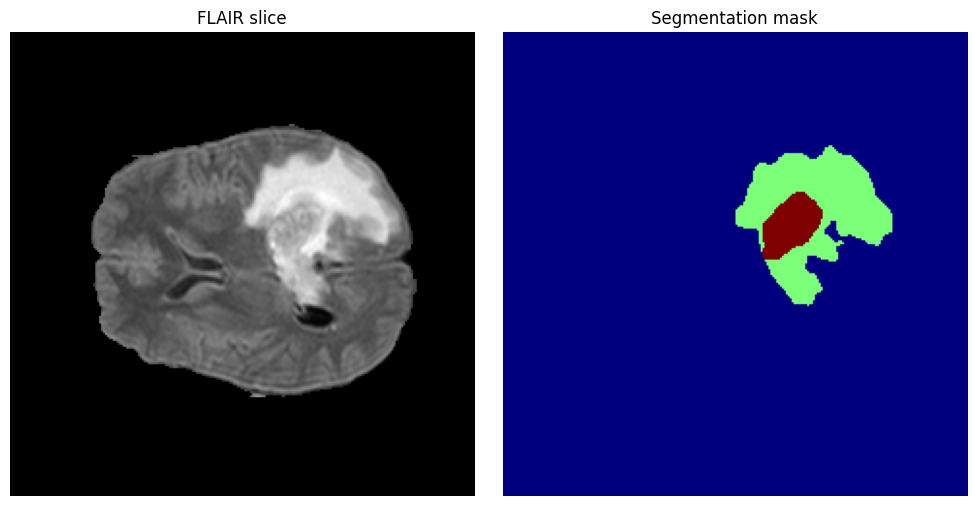

In [11]:
import matplotlib.pyplot as plt

slice_idx = 75  # middle-ish slice, we'll pick a better one shortly

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(flair_data[:, :, slice_idx], cmap='gray')
axes[0].set_title('FLAIR slice')
axes[0].axis('off')

axes[1].imshow(seg_data[:, :, slice_idx], cmap='jet')
axes[1].set_title('Segmentation mask')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [12]:
for idx in [30, 60, 90, 110, 140]:
    print(f"Slice {idx} unique labels:", np.unique(seg_data[:, :, idx]))

Slice 30 unique labels: [0.]
Slice 60 unique labels: [0. 2. 4.]
Slice 90 unique labels: [0. 2. 4.]
Slice 110 unique labels: [0. 2.]
Slice 140 unique labels: [0.]


In [18]:
import numpy as np

def remap_labels(seg_data):
    """
    BraTS labels are {0, 1, 2, 4} - not contiguous.
    Remap 4 -> 3 so labels become {0, 1, 2, 3}, which is required
    for standard loss functions (e.g. CrossEntropyLoss) that expect
    contiguous class indices starting at 0.
    """
    remapped = seg_data.copy()
    remapped[remapped == 4] = 3
    return remapped

In [19]:
remapped = remap_labels(seg_data)
print("Before:", np.unique(seg_data))
print("After:", np.unique(remapped))

Before: [0. 1. 2. 4.]
After: [0. 1. 2. 3.]


In [20]:
def normalize_volume(volume):
    """
    Z-score normalize a single MRI volume using only non-zero
    (brain tissue) voxels, so background zeros don't skew the stats.
    """
    mask = volume > 0
    mean = volume[mask].mean()
    std = volume[mask].std()
    normalized = (volume - mean) / (std + 1e-8)  # epsilon avoids divide-by-zero
    return normalized

In [21]:
normalized_flair = normalize_volume(flair_data)
print("Before - min:", flair_data.min(), "max:", flair_data.max())
print("After  - min:", normalized_flair.min(), "max:", normalized_flair.max())
print("After  - mean:", normalized_flair.mean(), "std:", normalized_flair.std())

Before - min: 0.0 max: 2570.0390625
After  - min: -2.948577371638422 max: 4.506513544946446
After  - mean: -2.419342410918568 std: 1.2082585919608628


In [22]:
import numpy as np


def remap_labels(seg_data):
    """
    BraTS labels are {0, 1, 2, 4} - not contiguous.
    Remap 4 -> 3 so labels become {0, 1, 2, 3}, which is required
    for standard loss functions (e.g. CrossEntropyLoss) that expect
    contiguous class indices starting at 0.
    """
    remapped = seg_data.copy()
    remapped[remapped == 4] = 3
    return remapped


def normalize_volume(volume):
    """
    Z-score normalize a single MRI volume using only non-zero
    (brain tissue) voxels, so background zeros don't skew the stats.
    """
    mask = volume > 0
    mean = volume[mask].mean()
    std = volume[mask].std()
    normalized = (volume - mean) / (std + 1e-8)  # epsilon avoids divide-by-zero
    return normalized

In [25]:
def get_tumor_slices(seg_data, min_tumor_pixels=50):
    """
    Returns a list of slice indices (along the depth axis) that contain
    a meaningful amount of tumor tissue.
    """
    tumor_slice_indices = []
    for idx in range(seg_data.shape[2]):
        slice_mask = seg_data[:, :, idx]
        tumor_pixel_count = np.sum(slice_mask > 0)
        if tumor_pixel_count >= min_tumor_pixels:
            tumor_slice_indices.append(idx)
    return tumor_slice_indices

In [26]:
tumor_slices = get_tumor_slices(seg_data)
print("Tumor-containing slices:", len(tumor_slices), "out of", seg_data.shape[2])
print("First few tumor slice indices:", tumor_slices[:10])

Tumor-containing slices: 75 out of 155
First few tumor slice indices: [45, 46, 47, 48, 49, 50, 51, 52, 53, 54]


## Preprocessing Summary

- Label remapping: BraTS labels {0,1,2,4} remapped to {0,1,2,3} for contiguous class indices
- Intensity normalization: per-volume z-score normalization using non-zero voxels only
- Tumor slice filtering: for a sample patient, 75/155 slices (48%) contained meaningful tumor tissue (min 50 pixels) — confirms need to filter tumor-free slices to avoid class imbalance during training

## Key EDA Findings

- The dataset contains 1252 patient records, each with four MRI modalities (T1, T1ce, T2, FLAIR) and a corresponding segmentation mask.
- Each MRI volume has a shape of (240, 240, 155), indicating 155 axial slices per patient.
- Intensity values across different volumes and modalities are not standardized (e.g., not 0-255), suggesting a need for per-volume normalization.
- Segmentation masks utilize labels: 0 for background, 1 for necrotic/non-enhancing core, 2 for edema, and 4 for enhancing tumor. Notably, label 3 is unused, which implies that label 4 should be remapped to 3 to ensure contiguous class indices for model training.
- Tumor presence is not uniform across all slices within a patient volume; some slices may not contain any tumor tissue.